# **A brief introduction to nonlinear programming**
Antoine Ackermann

In all this document, code will be written in Python.

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
np.seterr(over='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## **1. Unconstrained optimization**
### Task 1 : Oracle

In [2]:
def oracle(i, x, mode):
    
    match i:
        case 1:
            f_x = x[0]**2 + x[1]**2 - 2*x[0]*x[1]
            grad_f = [2*x[0]-2*x[1], 2*x[1]-2*x[0]]
            
        case 2:
            f_x = 10*(x[1] - x[0]**2)**2 + (1 - x[0])**2
            grad_f = [ -40*x[0]*(x[1] - x[0]**2) + 2*(x[0] - 1) ,  20*(x[1] - x[0]**2) ]
        
        case 3:
            x = np.asarray(x)
            f_x = 0.5*(sum(x[i]**2 for i in range(len(x))))
            grad_f = x.copy()

        case 4:
            f_x = sum((i+1)*x[i]**2+10*x[i]**4 for i in range(len(x)))
            grad_f = sum(2*(j+1)*x[j] + 40*x[j]**3 for j in range(len(x)))
            
            
    match mode:
        case 1: return f_x
        case 2: return (f_x, np.asarray(grad_f))
        case 3: return np.asarray(grad_f)

### Task 2 : Gradient descent

In [3]:
def Gradient(func, x0=(2, -2), step=0.005, tol=1e-6, MaxIt=1000, return_path=False):

    if return_path:
        path = [x0]
    
    x = np.asarray(x0, dtype=float)
    f, g = oracle(func, x, 2)
    it = 0

    while (np.linalg.norm(g) > tol) and (it < MaxIt):
        d = -g
        x = x + step * d
        f, g = oracle(func, x, 2)
        it += 1

        if return_path:
            path.append(x)

    if return_path:
        return path

    else:
        return x  

#### Question 1 : $f_1, f_2, f_3$ with $n=2$ 

In [4]:
list_x0 = list(itertools.product([-2, 2], repeat=2))          # (-2, -2), (-2, 2), (2, -2), (2, 2)
steps   = [5 * 10**-i for i in range(1, 4)]            # 0.5, 0.05, 0.005
funcs   = [1, 2, 3]

params = list(itertools.product(funcs, list_x0, steps))

for (f, x0, t) in params:
    print(f"f = {f} \t x0 = {x0} \t t = {t} \t -> \t x* = {Gradient(f, x0=x0, step=t)}") 

f = 1 	 x0 = (-2, -2) 	 t = 0.5 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, -2) 	 t = 0.05 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, -2) 	 t = 0.005 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, 2) 	 t = 0.5 	 -> 	 x* = [-2.  2.]
f = 1 	 x0 = (-2, 2) 	 t = 0.05 	 -> 	 x* = [-1.68499667e-07  1.68499667e-07]
f = 1 	 x0 = (-2, 2) 	 t = 0.005 	 -> 	 x* = [-1.76520379e-07  1.76520379e-07]
f = 1 	 x0 = (2, -2) 	 t = 0.5 	 -> 	 x* = [ 2. -2.]
f = 1 	 x0 = (2, -2) 	 t = 0.05 	 -> 	 x* = [ 1.68499667e-07 -1.68499667e-07]
f = 1 	 x0 = (2, -2) 	 t = 0.005 	 -> 	 x* = [ 1.76520379e-07 -1.76520379e-07]
f = 1 	 x0 = (2, 2) 	 t = 0.5 	 -> 	 x* = [2. 2.]
f = 1 	 x0 = (2, 2) 	 t = 0.05 	 -> 	 x* = [2. 2.]
f = 1 	 x0 = (2, 2) 	 t = 0.005 	 -> 	 x* = [2. 2.]
f = 2 	 x0 = (-2, -2) 	 t = 0.5 	 -> 	 x* = [-inf  inf]
f = 2 	 x0 = (-2, -2) 	 t = 0.05 	 -> 	 x* = [nan inf]
f = 2 	 x0 = (-2, -2) 	 t = 0.005 	 -> 	 x* = [0.95335261 0.90695338]
f = 2 	 x0 = (-2, 2) 	 t = 0.5 	 -> 	 x* = [-inf  inf]
f = 2 	 x0 = (-2, 2) 	 t =

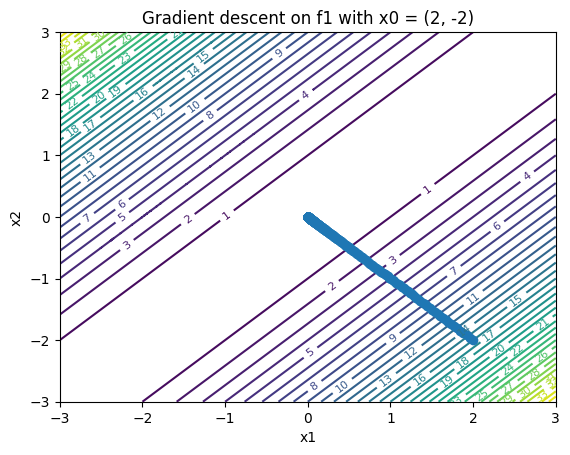

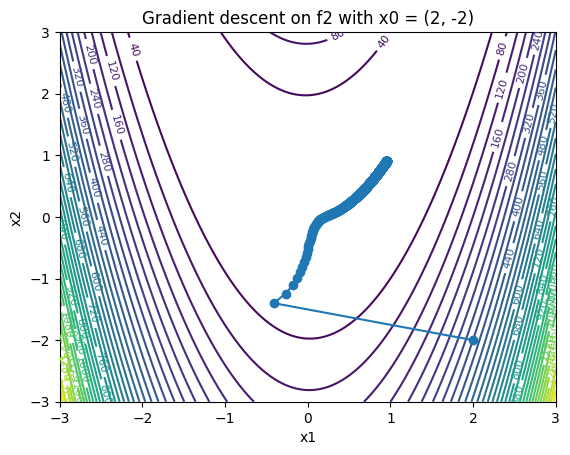

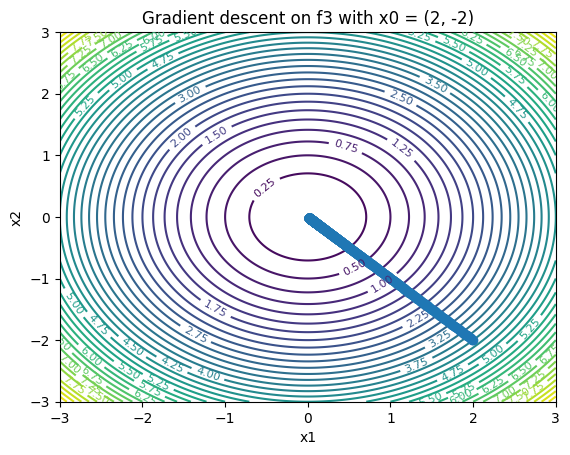

In [5]:
def draw_trajectory(f, x0=(2, -2)):
    
    # grid for level curves
    x1 = np.linspace(-3, 3, 400)
    x2 = np.linspace(-3, 3, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = oracle(f, (X1, X2), 1)  # f(x1,x2)

    # gradient trajectory
    traj = np.array(Gradient(f, x0=x0, step=0.005, MaxIt=1000, return_path=True))

    plt.figure()
    cs = plt.contour(X1, X2, Z, levels=40)   # level curves
    plt.clabel(cs, inline=True, fontsize=8)

    plt.plot(traj[:,0], traj[:,1], '-o')     # suite {x^k}
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Gradient descent on f{f} with x0 = {x0}')
    #plt.axis('equal')
    plt.show()

draw_trajectory(f=1)
draw_trajectory(f=2)
draw_trajectory(f=3)
    

#### Question 2 : $f_3$ with $n=10$ and $n=10000$

In [6]:
x0 = tuple((2 for i in range(10)))
print(f"With MaxIt = 1000 : x* = {Gradient(3, x0=x0, MaxIt=1000)} \n")
print(f"With MaxIt = 10000 : x* = {Gradient(3, x0=x0, MaxIt=10000)}")

With MaxIt = 1000 : x* = [0.01330794 0.01330794 0.01330794 0.01330794 0.01330794 0.01330794
 0.01330794 0.01330794 0.01330794 0.01330794] 

With MaxIt = 10000 : x* = [3.14888881e-07 3.14888881e-07 3.14888881e-07 3.14888881e-07
 3.14888881e-07 3.14888881e-07 3.14888881e-07 3.14888881e-07
 3.14888881e-07 3.14888881e-07]


In [7]:
x0 = tuple((2 for i in range(10000)))
print(f"With MaxIt = 1000 : x* = {Gradient(3, x0=x0, MaxIt=1000)}")
print(f"With MaxIt = 10000 : x* = {Gradient(3, x0=x0, MaxIt=10000)}")


With MaxIt = 1000 : x* = [0.01330794 0.01330794 0.01330794 ... 0.01330794 0.01330794 0.01330794]
With MaxIt = 10000 : x* = [9.96001425e-09 9.96001425e-09 9.96001425e-09 ... 9.96001425e-09
 9.96001425e-09 9.96001425e-09]


### Task 3 : Armijo's line search

In [8]:
def Armijo(func, x_k, d_k, t0=1e-4, theta=0.2, m=0.001, pmax=50):
    t = t0
    LHS = oracle(func, x_k+t*d_k, 1)
    RHS = oracle(func, x_k, 1)+m*t*np.dot(oracle(func, x_k, 3), d_k)
    
    p = 0
    
    while LHS > RHS and p < pmax:
        t *= theta
        LHS = oracle(func, x_k+t*d_k, 1)
        RHS = oracle(func, x_k, 1)+m*t*np.dot(oracle(func, x_k, 3), d_k)
        p += 1
        
        
    return t

### Task 4 : Gradient descent with Armijo's line search

In [9]:
def Gradient_w_Armijo(func, x0=(2, -2), step=0.005, tol=1e-6, MaxIt=1000):
    
    x = np.asarray(x0, dtype=float)
    f, g = oracle(func, x, 2)
    it = 0

    while (np.linalg.norm(g) > tol) and (it < MaxIt):

        d = -g
        t = Armijo(func, x, d)
        x = x + t * d
        f, g = oracle(func, x, 2)
        it += 1

    return x  

In [10]:
for (f, x0, t) in params:
    print(f"f = {f} \t x0 = {x0} \t t = {t} \t -> \t x* = {Gradient_w_Armijo(f, x0=x0, step=t)}") 

f = 1 	 x0 = (-2, -2) 	 t = 0.5 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, -2) 	 t = 0.05 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, -2) 	 t = 0.005 	 -> 	 x* = [-2. -2.]
f = 1 	 x0 = (-2, 2) 	 t = 0.5 	 -> 	 x* = [-1.34053282  1.34053282]
f = 1 	 x0 = (-2, 2) 	 t = 0.05 	 -> 	 x* = [-1.34053282  1.34053282]
f = 1 	 x0 = (-2, 2) 	 t = 0.005 	 -> 	 x* = [-1.34053282  1.34053282]
f = 1 	 x0 = (2, -2) 	 t = 0.5 	 -> 	 x* = [ 1.34053282 -1.34053282]
f = 1 	 x0 = (2, -2) 	 t = 0.05 	 -> 	 x* = [ 1.34053282 -1.34053282]
f = 1 	 x0 = (2, -2) 	 t = 0.005 	 -> 	 x* = [ 1.34053282 -1.34053282]
f = 1 	 x0 = (2, 2) 	 t = 0.5 	 -> 	 x* = [2. 2.]
f = 1 	 x0 = (2, 2) 	 t = 0.05 	 -> 	 x* = [2. 2.]
f = 1 	 x0 = (2, 2) 	 t = 0.005 	 -> 	 x* = [2. 2.]
f = 2 	 x0 = (-2, -2) 	 t = 0.5 	 -> 	 x* = [ 0.04405651 -0.22300639]
f = 2 	 x0 = (-2, -2) 	 t = 0.05 	 -> 	 x* = [ 0.04405651 -0.22300639]
f = 2 	 x0 = (-2, -2) 	 t = 0.005 	 -> 	 x* = [ 0.04405651 -0.22300639]
f = 2 	 x0 = (-2, 2) 	 t = 0.5 	 -> 	 x* = [-1.39

### Task 5: Gradient descent with Armijo's line search on $f_4$ 

We compute the partial derivatives of $f_4$ with respect to $x_j$ : 
$\frac{\partial (i x_i^2 + 10x_i^4)}{\partial x_j}(x) = \begin{cases} 2j \cdot x_j + 40 x_j^3 \quad \text{if} \quad i=j \\ 0 \quad \text{otherwise} \end{cases}  $ hence :
$$ \nabla f_4(x) = (2 \cdot 1  x_1 + 40 x_1^3, \ldots, 2 \cdot n x_n + 40 x_n^3) $$

In [11]:
n = 10
x0 = [10 for i in range(n-1)] + [-10]

print(f"For n = {n} : x* = {Gradient_w_Armijo(4, x0=x0)}") 

For n = 10 : x* = [  6.48867488   6.48867488   6.48867488   6.48867488   6.48867488
   6.48867488   6.48867488   6.48867488   6.48867488 -13.51132512]


## **2. Constrained optimization: a variant of the LASSO problem**

### Question 1 : convexity

The problem is convex if and only if (i) the objective function is convex and (ii) the feasible set is convex.

(i) $ f:x \rightarrow y-Hx $ is linear, therefore convex. Likewise, $g: x \rightarrow || x ||^2$ is convex. Since $f_5 = g \circ f$ is a composition of two convex functions, $f_5$ is itself convex. 

(ii) Let $x, y \in \{z, ||z||_1 \leq \tau\} $. Let $\lambda \in \mathbb{R}$. Since the norm is subadditive, $$ || \lambda x + (1-\lambda y) ||_1 \leq || \lambda x ||_1 + || \lambda y ||_1 \\
\leq |\lambda| \cdot \|x\|_1 + |1-\lambda| \cdot \|y\|_1
$$

Given that $ \lambda \geq 0 $ and $ 1-\lambda \geq 0 $, we get: $
\| \lambda x + (1-\lambda)y \|_1 \leq \lambda \cdot \|x\|_1 + (1-\lambda) \cdot \|y\|_1$. Since $ x, y \in \mathcal{S} $, then: $\| \lambda x + (1-\lambda)y \|_1 \leq \lambda \tau + (1-\lambda)\tau = \tau$

So: $\lambda x + (1-\lambda)y \in \mathcal{S}$ and therefore: $\mathcal{S} \text{ is convex.}$

Conclusion : the problem is convex.


### Question 2 : Oracle

In [12]:
def oracle(x, y, H):
    
    f_x = 0.5 * np.linalg.norm(y - H @ x)**2
    grad_f_x = H.T @ ( H@x - y )
    
    return f_x, grad_f_x

### Question 3 : Generic solution


Let $ x, c \in \mathbb{R}^n $. We write:
$
x = \begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{pmatrix}
\quad \text{and} \quad
c = \begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix}
$

We could solve the problem formally by linearizing $ |x_i| = u_i^+ + u_i^- $ and then using the Lagrangian and KKT conditions.

Intuitively however, since we want to minimize $ c^\top x = c_1 x_1 + c_2 x_2 + \dots + c_n x_n $, we can allocate the full weight of $ \|x\| $ to the component $ x_i $ such that $ |c_i| $ is highest. In this case, $ x_i $ must have the opposite sign of $ c_i $ (i.e., if $ c_i $ is negative, $ x_i $ must be positive since we are looking to minimize, and vice-versa).

Mathematically:
$
i^* = \arg\max_i |c_i| $ and $
x_j^* = \begin{cases}
-\tau \, \text{sgn}(c_{i^*}) & \text{if } j = i^* \\
0 & \text{otherwise}
\end{cases}
$


### Question 4 : Frank-Wolfe Algorithm for LASSO

In [13]:
def FWA(x0, y, H, tau=24, tol=0.1, MaxIt = 10000):
    """Frank–Wolfe Algorithm for LASSO optimisation problem : 
     min 0.5 ||y - Hx||²  tel que ||x||_1 ≤ τ
  """
    
    x_k = x0.copy()
    k = 0
    
    f_x, grad_f_x = oracle(x_k, y, H)
    
    i_star = np.argmax(np.abs(grad_f_x)) # argument de la valeur absolue max
    s_k = np.zeros_like(x_k) # vecteur nul de même format que x_k
    s_k[i_star] = -tau*np.sign(grad_f_x[i_star])  
    
    
    while -grad_f_x.T @ (s_k - x_k) > tol and k <= MaxIt: 
        
             
        # 1 : descent direction
        d_k = s_k-x_k
        
        # 2 : simplified line search  
        t_k = 2/(2+k)
        
        # 3 : optimal x update
        x_k += t_k*d_k
        
        # 4 : new gradient and extreme direction
        f_x, grad_f_x = oracle(x_k, y, H)

        
        i_star = np.argmax(np.abs(grad_f_x))
        s_k = np.zeros_like(x_k)
        s_k[i_star] = -tau*np.sign(grad_f_x[i_star]) # extreme direction
        
        # 5 : update counter
        k += 1

    print(f"Number of iterations : {k}")
  
    return x_k

### Question 5 : test using $H$ and $\tau = 24$

Number of iterations : 3300
f(x*) = 2.1045140380390848


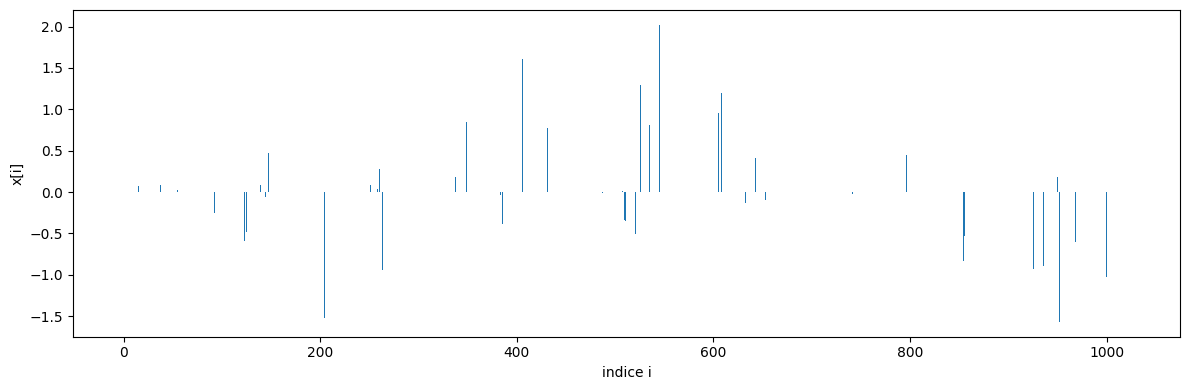

In [14]:
H = np.genfromtxt("H.csv", delimiter=",")
y = np.genfromtxt("y.csv", delimiter=",") 

x_sol = FWA(np.zeros(H.shape[1]), y, H)

print(f"f(x*) = {oracle(x_sol, y, H)[0]}")
components = [f"x{i}" for i in range(len(x_sol))]

n = x_sol.size
x = np.arange(n)             # indices 0,...,1023

plt.figure(figsize=(12,4))   
plt.bar(x, x_sol, width=1.0)     
plt.xlabel("indice i")
plt.ylabel("x[i]")
plt.tight_layout()
plt.show()